In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import copy
import time
from abc import ABC, abstractmethod
from typing import List, Tuple, Type
import qmcpy
from scipy.stats import norm 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel 
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
def generate_sobol_points(bounds: List[Tuple[float, float]] , num_points: int) -> np.ndarray:
    distribution = qmcpy.Sobol(dimension=len(bounds))
    pts01 = distribution.gen_samples(n=2 ** np.ceil(np.log2(num_points)))[:num_points]
    pts_scale = np.array([domain[1]-domain[0] for domain in bounds])
    pts_min = np.array([domain[0] for domain in bounds])
    return pts_min + pts_scale * pts01

In [4]:
class GaussianProcessModel(GaussianProcessRegressor):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.is_fit = False

    def fit(self, X, y):
        super().fit(X, y)
        self.is_fit = True
        return self 
    
    def mean(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling mean.")
        return self.predict(X, return_std=False) 
    
    def variance(self, X: np.ndarray) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling variance.")
        _, std = self.predict(X, return_std=True)
        return std**2
    
    def sample(self, X: np.ndarray, n_samples: int=1) -> np.ndarray:
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling sample.")
        result = self.sample_y(X, n_samples=n_samples, random_state=1234)
        
        return result
    
    def update(self, X_new: np.ndarray, y_new: np.ndarray):
        if not self.is_fit:
            raise RuntimeError("Model must be fit before calling update.")
        X_combined = np.concatenate((self.X_train_, X_new), axis=0)
        y_combined = np.concatenate((self.y_train_, y_new), axis=0)
        self.fit(X_combined, y_combined)
        return self 
    
    def min(self, bounds: List[Tuple[float, float]] , num_points: int=1000):
        points = generate_sobol_points(bounds, num_points)
        posterior_mean = self.predict(points, return_std=False)
        idx = np.argmin(posterior_mean)

        return points[[idx], : ], posterior_mean[idx]
        

In [5]:
class Policy(ABC):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]] = None
            ):
        self.model = model
        self.bounds = bounds

    @abstractmethod
    def evaluate(self, points: np.ndarray) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        raise NotImplementedError 
    
    def optimize(self, n_grid_points: int=1000) -> np.ndarray:
        """
        return: (D,)
        """
        points = generate_sobol_points(self.bounds, n_grid_points)
        vals = self.evaluate(points)
        idx = np.argmax(vals)

        return points[[idx], : ] 

In [6]:
class ExpectedImprovement(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
            ):
        super().__init__(model, bounds)

    def evaluate(self, points: np.ndarray) -> np.ndarray:
        """
        points: (M, D)
        return: (M,)
        """
        mu = self.model.mean(points)
        sigma2 = self.model.variance(points)
        sigma = np.sqrt(sigma2)
        f_min = self.model.predict(self.model.X_train_)[0].min()
        z = (f_min - mu)/np.fmax(sigma, 1e-8)
        cdf_z = norm.cdf(z)
        pdf_z = norm.pdf(z)

        return (sigma * np.fmax(0.0, z * cdf_z + pdf_z))

In [7]:
class MDPRollOut(Policy):
    def __init__(self, 
                 model: GaussianProcessModel, 
                 bounds: List[Tuple[float, float]],
                 horizon: int,
                 base_policy: Type[Policy], 
                 n_samples: int = int(1e2)
                ):
        super().__init__(model, bounds)
        self.horizon = horizon
        self.n_samples = n_samples
        self.base_policy = base_policy

    def evaluate(self, points: np.ndarray) -> np.ndarray:
        rewards = np.zeros((points.shape[0], self.n_samples,))
        for i in range(0, points.shape[0]):
            for j in range(0, self.n_samples):
                r = self.draw_from_policy(points[i].reshape(1, -1))
                rewards[i, j] = r.item() if isinstance(r, np.ndarray) else r

        return rewards.mean(axis=1)

    # Execute policy once using sequential draws from GPs
    def draw_from_policy(self, x):
        reward = 0.0
        model = copy.deepcopy(self.model)
        xi = copy.deepcopy(x)
        h = self.horizon

        while(True):
            # import pdb 
            # pdb.set_trace()
            
            fi = model.sample(xi)
            # get current reward from base policy
            acqf = self.base_policy(model, self.bounds)
            ri = acqf.evaluate(xi).item()

            reward += ri
            h = h - 1
            if h <= 0:
                break
            
            model = model.update(xi, fi)
            acqf = self.base_policy(model, self.bounds)
            xi = acqf.optimize()
        
        return reward

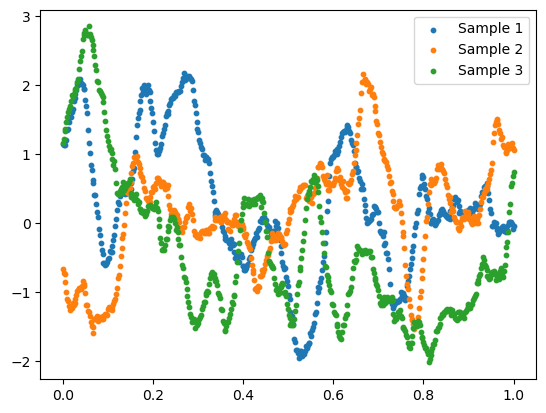

In [8]:
kernel = Matern(length_scale=0.05, nu=1.5, length_scale_bounds=(0.01, 1.0)) + \
      WhiteKernel(noise_level=1e-3 , noise_level_bounds=(1e-4, 1e-2))
test_gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
X_test = np.atleast_2d(np.linspace(0, 1, 500)).T
test_gp_samples = test_gp.sample_y(X_test, n_samples=3, random_state=1234)
fig, ax = plt.subplots()
for i in range(test_gp_samples.shape[1]):
    ax.scatter(X_test, test_gp_samples[:, i], s = 10, label=f'Sample {i+1}')
ax.legend()
plt.show()

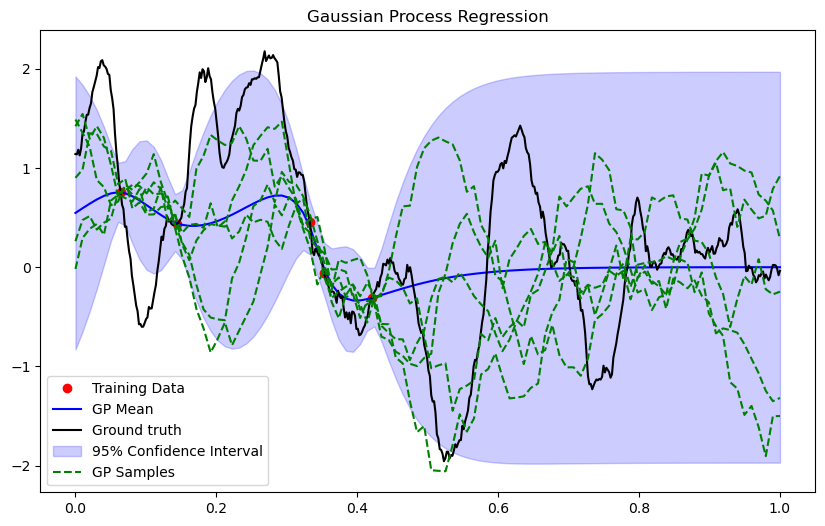

In [16]:
# Check GP model 
# bounds = [(0.0, 20.0)]
# train_x = np.random.uniform(low=bounds[0][0], high=bounds[0][1], size=(5, 1))
# train_y = np.sin(20*train_x) + 20*(train_x-0.3)**2 
# params = {}

# train_x = np.linspace(0.15, 0.85, 2)[:, None]
# train_y = np.array([0, 0])[:, None]
# bounds = [(0.0, 1.0)]
# params = {}

bounds = [(0.0, 1.0)]
ind = np.random.randint(X_test.shape[0], size=(5, 1))
train_x = X_test[ind].reshape(5,1)
train_y = test_gp_samples[ind, 0].reshape(5,1)
ground_truth_y = test_gp_samples[:, 0]

kernel = Matern(length_scale=0.01, 
                nu=1.5, 
                length_scale_bounds=(0.01, 1.0)
                ) + \
        WhiteKernel(noise_level=1e-3 , 
                    noise_level_bounds=(1e-4, 1e-2)
                )
params = {"kernel" : kernel}
gp = GaussianProcessModel(**params).fit(train_x, train_y)
test_x = np.linspace(bounds[0][0], bounds[0][1], 100).reshape(-1, 1)
mean = gp.mean(test_x)
var = gp.variance(test_x)
samples = gp.sample(test_x, n_samples=5)
plt.figure(figsize=(10, 6))
plt.plot(train_x, train_y, 'ro', label='Training Data')
plt.plot(test_x, mean, 'b-', label='GP Mean')
plt.plot(X_test, ground_truth_y, "k-", label="Ground truth")
plt.fill_between(test_x.flatten(), 
                 mean - 1.96 * np.sqrt(var), 
                 mean + 1.96 * np.sqrt(var), 
                 color='blue', 
                 alpha=0.2, 
                 label='95% Confidence Interval'
                )
for i in range(samples.shape[1]):
    plt.plot(test_x, samples[:,i], "g--", label='GP Samples' if i==0 else None)
# plt.plot(test_x, samples, 'g--', label='GP Samples')
plt.legend()
plt.title('Gaussian Process Regression')
plt.show()

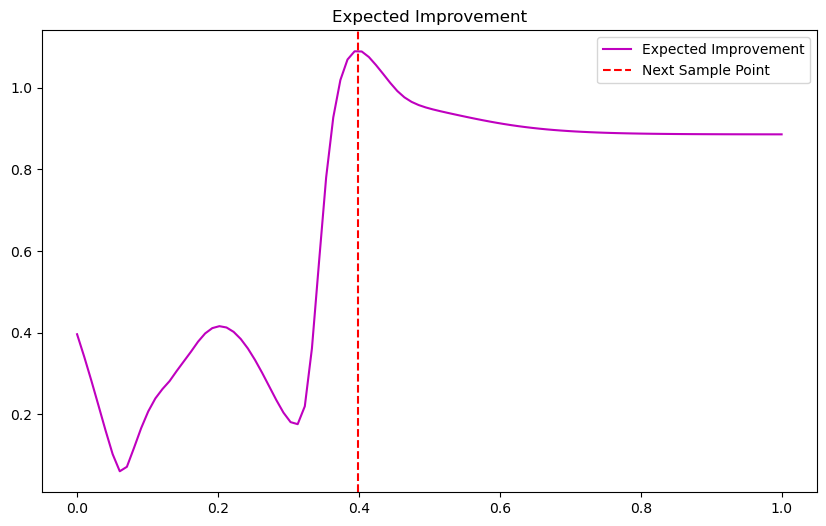

In [17]:
# Check EI policy
ei_policy = ExpectedImprovement(gp, bounds)
next_x = ei_policy.optimize()
ei_values = ei_policy.evaluate(test_x)
plt.figure(figsize=(10, 6))
plt.plot(test_x, ei_values, 'm-', label='Expected Improvement')
plt.axvline(next_x, color='r', linestyle='--', label='Next Sample Point')
plt.legend()
plt.title('Expected Improvement')
plt.show()

In [18]:
# Check MDP Rollout policy
mdp_policy = MDPRollOut(gp, 
                        bounds, 
                        horizon=2, 
                        base_policy=ExpectedImprovement,
                        n_samples=16
                    )   
next_x_mdp = mdp_policy.optimize(n_grid_points=100)

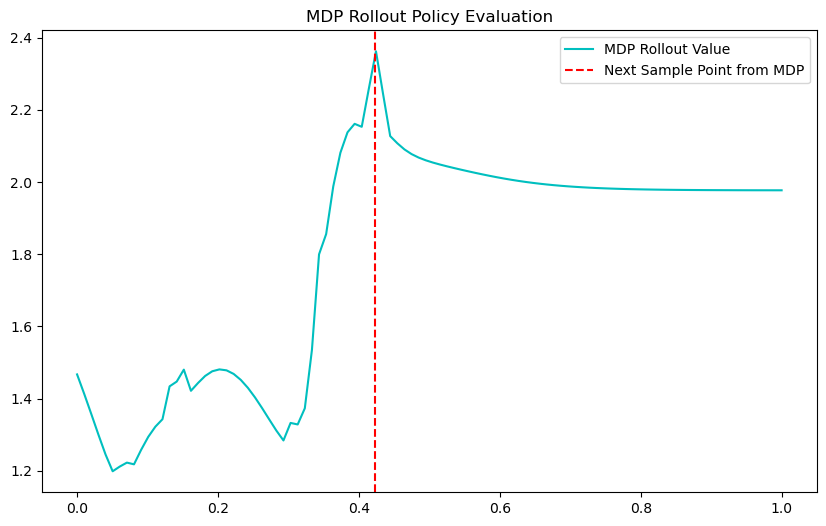

In [19]:
mdp_values = mdp_policy.evaluate(test_x)
plt.figure(figsize=(10, 6))
plt.plot(test_x, mdp_values, 'c-', label='MDP Rollout Value')
plt.axvline(next_x_mdp, color='r', linestyle='--', label='Next Sample Point from MDP')
plt.legend()
plt.title('MDP Rollout Policy Evaluation')
plt.show()

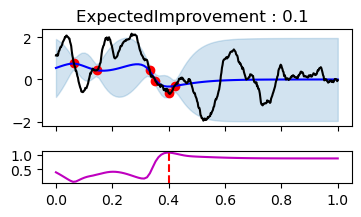

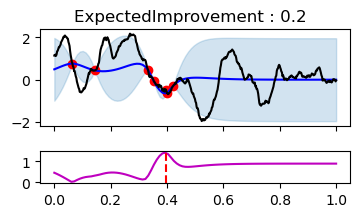

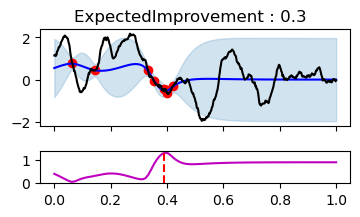

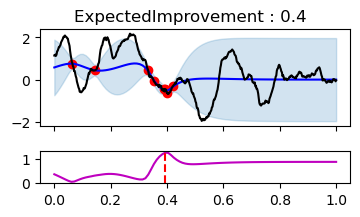

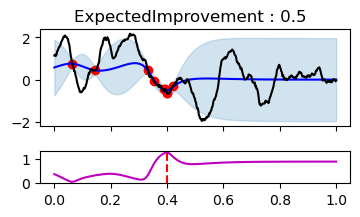

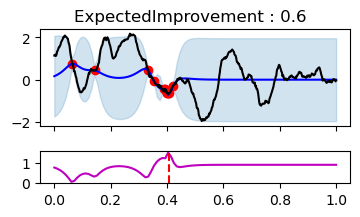

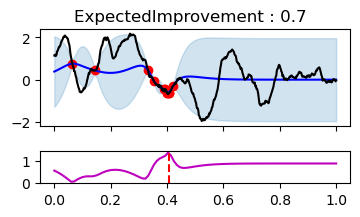

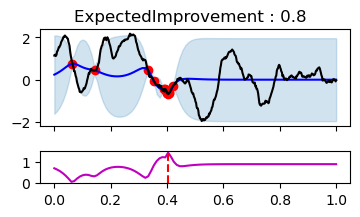

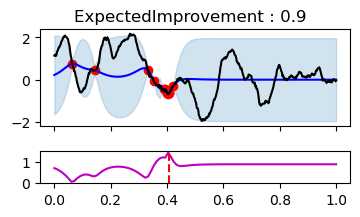

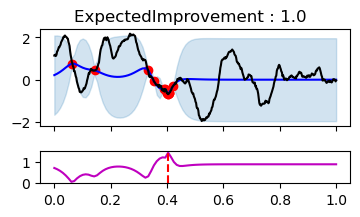

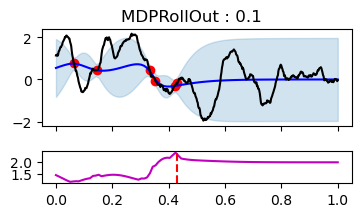

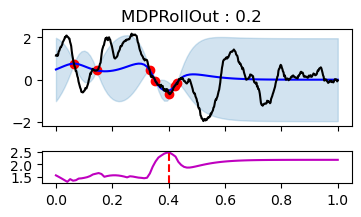

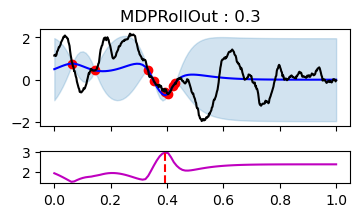

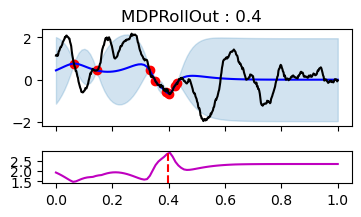

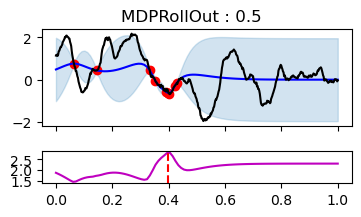

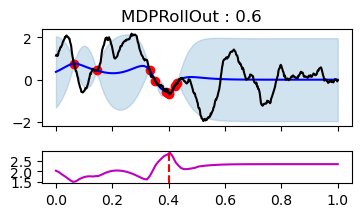

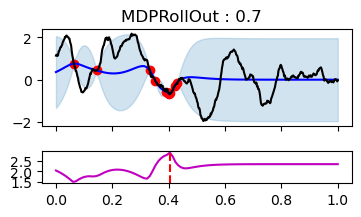

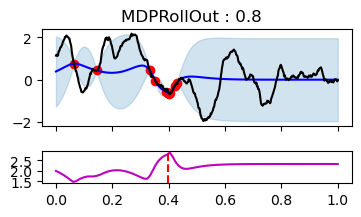

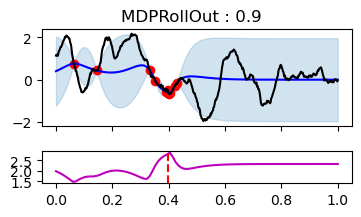

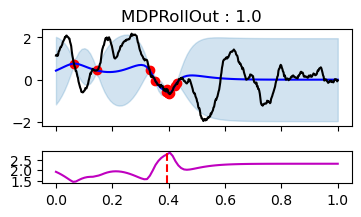

In [20]:
# Simple Bayesian Optimization
ei_policy = lambda model : ExpectedImprovement(model, bounds)
ei_mdp = lambda model : MDPRollOut(model, 
                                   bounds, 
                                   horizon=2, 
                                   base_policy=ExpectedImprovement,
                                   n_samples = 32
                                )

progress = np.zeros((2,10))
for i, p in enumerate([ei_policy, ei_mdp]):
    xi, yi = copy.deepcopy(train_x), copy.deepcopy(train_y)
    for j in range(10):
        gp = GaussianProcessModel(**params).fit(xi, yi)
        _,best_y = gp.min(bounds)
        progress[i,j] = best_y
        policy = p(gp)
        next_x = policy.optimize(n_grid_points=100)
        fi = ground_truth_y[:,None][((X_test-next_x)**2).argmin()]

        xi = np.concatenate((xi, next_x), axis=0)
        yi = np.concatenate((yi, fi.reshape(-1,1)), axis=0)

        fig, axs = plt.subplots(2, 1, 
                                figsize=(2*2, 2), 
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True
                            )
        fig.subplots_adjust(hspace=0.4)
        fig.suptitle(f"{type(policy).__name__} : {(j+1)/10}")
        ax = axs[0]
        mean = gp.mean(test_x)
        var = gp.variance(test_x)
        ax.plot(xi, yi, 'ro', label='Training Data')
        ax.plot(test_x, mean, 'b-', label='GP Mean')
        ax.plot(X_test, ground_truth_y, "k-", label="Ground truth")
        ax.fill_between(test_x.flatten(), 
                        mean - 1.96 * np.sqrt(var), 
                        mean + 1.96 * np.sqrt(var), 
                        color='tab:blue', 
                        alpha=0.2, 
                        label='95% Confidence Interval'
                    )
        
        ax = axs[1]
        values = policy.evaluate(test_x)
        ax.plot(test_x, values, 'm-',)
        ax.axvline(next_x, color="r", ls="--")

        plt.show()

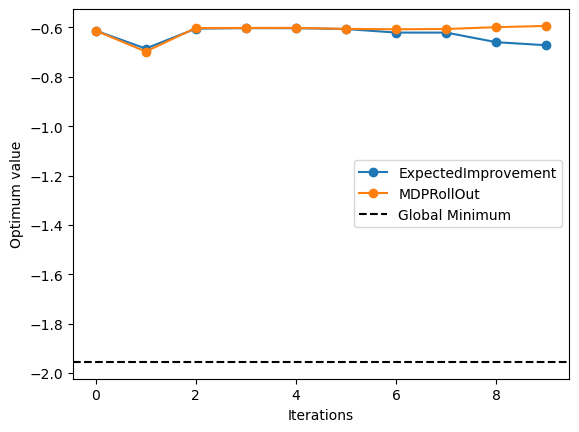

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.arange(progress.shape[1]), progress[0,:],"o-", label="ExpectedImprovement")
ax.plot(np.arange(progress.shape[1]), progress[1,:],"o-", label="MDPRollOut")
ax.axhline(min(ground_truth_y), color="k", ls='--', label="Global Minimum")
ax.set_xlabel("Iterations")
ax.set_ylabel("Optimum value")
ax.legend()
plt.show()